# Shooting Incidents in New York City


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import calendar
import math
import json

# Folium
import folium
from folium import Icon
from folium.plugins import HeatMap, MarkerCluster, HeatMapWithTime

# Plotly
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.ticker as ticker

# Bokeh
from bokeh.io import output_notebook
from bokeh.plotting import figure, show, output_file
from bokeh.layouts import column
from bokeh.models import (
    ColumnDataSource, HoverTool, Select, CustomJS, LabelSet,
    LinearColorMapper, ColorBar, BasicTicker, Legend, Spacer
)
from bokeh.transform import transform
from bokeh.palettes import Category10, RdBu, Reds256, Blues256, Greys256

# Calplot
import calplot

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# PyGAM
from pygam import PoissonGAM, s

# Motivation


>What is your dataset?\
Why did you choose this/these particular dataset(s)?\
What was your goal for the end user's experience?

>Our primary dataset is the NYPD Shooting Incident Data (Historic), which provides a detailed record of every shooting incident in New York City from 2006 to 2004, sourced from NYC Open Data (https://data.cityofnewyork.us/Public-Safety/NYPD-Shooting-Incident-Data-Historic-/833y-fsy8). It includes event details, locations, times, and demographics of suspects and victims. We also incorporated the NYC Weather dataset (2016 to 2022) from Kaggle (https://www.kaggle.com/datasets/aadimator/nyc-weather-2016-to-2022/data), which covers weather conditions in NYC over that period, allowing us to analyze shooting trends alongside weather patterns for the overlapping years.</br>
We chose these datasets because they allow us to examine how violent crime and environmental factors interact in NYC, a city that is a major tourist destination. The shooting data gives us a close look at what happens over a big time period and enables us to more clearly see threats to safety, and the weather data gives us the capability to see if weather conditions like temperature or rain affect how often shootings happen. Being a community concerned with city safety, we were interested in knowing if and how NYC is unsafe for visitors, especially tourist attractions, and if weather conditions contribute to such unsafety.</br>
Our aim for the end user experience is to develop an interactive article with data visualizations embedded in it that enables tourists and their families to interpret the safety profile of New York City. By using visualizations like maps of where shootings are occurring, trends over time, and comparisons to weather, readers can make decisions about where and when is safest. This enables them to make better decisions when they are out and about. They can, for example, check whether popular spots are near danger zones, if there are safer times of day to be out, or if rainy days are lighter on crime. The idea is to present these concepts in a simplified format in the article in a manner that anyone organizing a trip to NYC will be better prepared and self-assured.


# Loading the dataset

In [42]:
# Set pandas display options to show all columns for .head command
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)       # Auto-detect the display width
pd.set_option('display.max_colwidth', None) # Show full content of each column

# Loading the datasets
file_path = '/Users/chenxi/Documents/DTU - Computer Science/02806 - Social Data/NYPD_Shooting_Incident_Data__Historic__20250403.csv'
file_path2 = '/Users/chenxi/Documents/DTU - Computer Science/02806 - Social Data/NYC_Weather_2016_2022.csv'

data = pd.read_csv(file_path)
data2 = pd.read_csv(file_path2)

# Data cleaning
>Basic stats. Let's understand the dataset better\
Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis.

>To better understand our datasets, we examined their structure and content. The NYPD Shooting Incident Data (Historic) contains records of shooting incidents in NYC from 2006 onward, with columns like incident date, time, location (borough and coordinates), and victim/suspect demographics (age, sex, race). The NYC Weather dataset (2016 to 2022) provides daily weather data, including temperature, precipitation, humidity, and wind speed, recorded at a central NYC station. Since the shooting data spans a longer period, we focused on the overlapping years (2016–2022) for our combined analysis, ensuring temporal alignment for studying weather’s impact on shooting incidents.
>Write about your choices in data cleaning and preprocessing

>Our cleaning and preprocessing strategy was tailored for each dataset. For the shooting incident data, we removed descriptive and administrative fields not relevant to our analysis, streamlined naming conventions for clarity, and ensured consistency in formatting. We verified the completeness of key temporal and spatial information, filtering the data to the relevant time frame and removing entries with missing location data. To support temporal analysis, we extracted and structured components like year, month, and hour, then aggregated the data on a daily basis to align with the weather dataset.


In [43]:
#Incident dataset
#Removing specific columns by name
columns_to_remove = ['INCIDENT_KEY','LOC_OF_OCCUR_DESC', 'JURISDICTION_CODE','LOC_CLASSFCTN_DESC','LOCATION_DESC','PERP_AGE_GROUP','PERP_SEX','VIC_AGE_GROUP','VIC_SEX','X_COORD_CD','Y_COORD_CD','Lon_Lat']
data = data.drop(columns=columns_to_remove)
data = data.rename(columns={'OCCUR_DATE': 'date', 'OCCUR_TIME': 'time', 'STATISTICAL_MURDER_FLAG': 'ifdead', 'Latitude': 'lat', 'Longitude': 'lon'})
data.columns = data.columns.str.lower()

In [44]:
#Check if there's missing values in date and time
column_name = ['date','time','lat','lon']
has_missing = data[column_name].isna().any()

In [45]:
#filtering the data > 2016
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y')
# Remove rows where the date is before 2016-01-01
data = data[data['date'] >= '2016-01-01']
data = data[data['date'] <= '2022-10-26']
data = data[
    ~(data['lat'].isna() | data['lon'].isna())
]

In [46]:
# Drop rows where any of the specified columns have missing values
column_name = ['lat', 'lon']
cleaned_data = data.dropna(subset=column_name).reset_index(drop=True)


In [47]:
#Datetime splitting into year, month and hour
data['date'] = data['date'].astype(str)
data['time'] = data['time'].astype(str)
data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'])
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['hour'] = data['datetime'].dt.hour

data = data.drop(columns=[ 'day','time', 'datetime'])

data.head(5)

,date,boro,precinct,ifdead,perp_race,vic_race,lat,lon,year,month,hour
0,2021-08-09,BRONX,40,False,NaN,BLACK,40.809673,-73.920193,2021,8,1
1,2018-04-07,BROOKLYN,79,True,WHITE HISPANIC,BLACK,40.685610,-73.942913,2018,4,19
9,2016-05-07,BROOKLYN,69,False,BLACK,BLACK,40.640009,-73.901933,2016,5,15
14,2018-09-17,BROOKLYN,76,True,NaN,BLACK,40.684281,-73.989344,2018,9,16
16,2016-07-05,BRONX,41,False,WHITE HISPANIC,BLACK,40.812519,-73.902812,2016,7,20


>For the weather data, we focused on temperature, rain cloudcover and windspeed. After simplifying and renaming the relevant columns, we formatted the time information to match the structure used in the incident data. 

In [48]:
#Weather dataset
#Removing specific columns by name
columns_to_remove = ['precipitation (mm)','cloudcover_low (%)','cloudcover_mid (%)','cloudcover_high (%)','winddirection_10m (°)']
data2 = data2.drop(columns=columns_to_remove)
data2 = data2.rename(columns={'temperature_2m (°C)': 'temperature', 'rain (mm)': 'rain', 'windspeed_10m (km/h)': 'windspeed','cloudcover (%)':'cloudcover'})
data2.columns = data2.columns.str.lower()


In [49]:
#Datetime splitting into year, month and hour
data2['time'] = pd.to_datetime(data2['time'])
data2['year'] = data2['time'].dt.year
data2['day'] = data2['time'].dt.date
data2['hour'] = data2['time'].dt.hour
data2['month'] = data2['time'].dt.month

data2 = data2.drop(columns=['time'])
data2.head(5)

,temperature,rain,cloudcover,windspeed,year,day,hour,month
0,7.6,0.0,69.0,10.0,2016,2016-01-01,0,1
1,7.5,0.0,20.0,9.8,2016,2016-01-01,1,1
2,7.1,0.0,32.0,9.7,2016,2016-01-01,2,1
3,6.6,0.0,35.0,9.2,2016,2016-01-01,3,1
4,6.3,0.0,34.0,9.1,2016,2016-01-01,4,1


In [50]:
# Drop rows where any of the specified columns have missing values
column_name = ['temperature', 'rain','cloudcover']
cleaned_data = data2.dropna(subset=column_name).reset_index(drop=True)


# Data analysis
### Shooting Incident dataset
Describe your data analysis and explain what you've learned about the dataset.
<br>If relevant, talk about your machine-learning.

In [51]:
year_cat = data.pivot_table(index='year', columns='boro', aggfunc='size', fill_value=0)
year_cat.head(5)

boro,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
year,,,,,
2016,308,498,167,191,44
2017,306,357,117,144,46
2018,313,365,105,150,25
2019,267,372,146,156,26
2020,504,819,272,303,50


In [62]:
# Enable notebook output
output_notebook()

# Save as HTML
output_file("shooting_incidents.html")

# Assuming 'data' is the dataframe (df = data)
# df = data  # Uncomment and replace with your actual dataframe

# Count the number of incidents (by month and by year)
def count_incidents(df, group_by):
    return df.groupby(['boro', group_by]).size().reset_index(name='count')

month_data = count_incidents(df, 'month')
year_data = count_incidents(df, 'year')

# Get all boroughs
boros = df['boro'].unique()

# Color mapping
colors = Category10[len(boros)]
color_map = {boro: colors[i] for i, boro in enumerate(boros)}

# Create ColumnDataSource
boro_sources = {
    "month": {boro: ColumnDataSource(month_data[month_data['boro'] == boro]) for boro in boros},
    "year": {boro: ColumnDataSource(year_data[year_data['boro'] == boro]) for boro in boros}
}

# Create HoverTool 
hover = HoverTool(tooltips=[("Borough", "@boro"), ("Count", "@count")])

# Create two line charts with larger width
p_month = figure(title="Shooting Incidents by Month", x_axis_label="Month", y_axis_label="Number of Incidents", 
                 width=800, height=500, toolbar_location="above")
p_year = figure(title="Shooting Incidents by Year", x_axis_label="Year", y_axis_label="Number of Incidents", 
                width=800, height=500, visible=False, toolbar_location="above")

p_month.add_tools(hover)
p_year.add_tools(hover)

# Plot lines with bullet markers using scatter and create legend items
legend_items_month = []
legend_items_year = []
for boro in boros:
    # Month plot
    line_month = p_month.line(x='month', y='count', source=boro_sources['month'][boro], 
                              line_width=2, color=color_map[boro])
    scatter_month = p_month.scatter(x='month', y='count', source=boro_sources['month'][boro], 
                                   size=6, color=color_map[boro], fill_alpha=0.5)
    legend_items_month.append((boro, [line_month, scatter_month]))
    
    # Year plot
    line_year = p_year.line(x='year', y='count', source=boro_sources['year'][boro], 
                            line_width=2, color=color_map[boro])
    scatter_year = p_year.scatter(x='year', y='count', source=boro_sources['year'][boro], 
                                 size=6, color=color_map[boro], fill_alpha=0.5)
    legend_items_year.append((boro, [line_year, scatter_year]))

# Create external legends positioned at top-right
legend_month = Legend(items=legend_items_month, title="Borough", click_policy="hide", 
                      location="top_right", orientation="vertical", border_line_width=1,
                      background_fill_color="white", background_fill_alpha=0.8, 
                      padding=5, spacing=2, label_text_font_size="10pt")
legend_year = Legend(items=legend_items_year, title="Borough", click_policy="hide", 
                     location="top_right", orientation="vertical", border_line_width=1,
                     background_fill_color="white", background_fill_alpha=0.8,
                     padding=5, spacing=2, label_text_font_size="10pt")

# Add legends to the plots (top-right corner)
p_month.add_layout(legend_month)
p_year.add_layout(legend_year)

# Center the title and style axes
for p in [p_month, p_year]:
    p.title.align = "center"
    p.title.text_font_size = "14pt"
    p.xaxis.axis_label_text_font_size = "12pt"
    p.yaxis.axis_label_text_font_size = "12pt"
    p.xaxis.major_label_text_font_size = "10pt"
    p.yaxis.major_label_text_font_size = "10pt"
    p.background_fill_color = "white"
    p.border_fill_color = "white"

# Create selection box (month or year)
select = Select(title="Select Grouping:", value="month", options=["month", "year"])

# JavaScript callback function
callback = CustomJS(args=dict(select=select, p_month=p_month, p_year=p_year), code="""
    var selected_value = select.value;
    if (selected_value === 'month') {
        p_month.visible = true;
        p_year.visible = false;
    } else {
        p_month.visible = false;
        p_year.visible = true;
    }
""")

select.js_on_change('value', callback)

# Layout with plots and legend
layout = column(select, p_month, p_year)

# Show in notebook and export to HTML
show(layout)

Loading BokehJS ...

>To help our readers more easily visualize trends in shooting incidents, we built an interactive line graph of incidents by NYC borough that enables visualization by year or month. The annual perspective witnessed the Brooklyn and Bronx cases reach their peaks in 2020 with more than 600 and 800 cases respectively, then declining to approximately 200 and 300 by 2022, with Manhattan consistently remaining below 150 cases per annum, a testament to its relative safety. The monthly pattern showed a definite seasonal trend, with Brooklyn and the Bronx reaching 400–500 incidents in June–July and falling in January–February to 100–150 or so, indicating that summer visits are riskier than in winter, particularly outside Manhattan. 

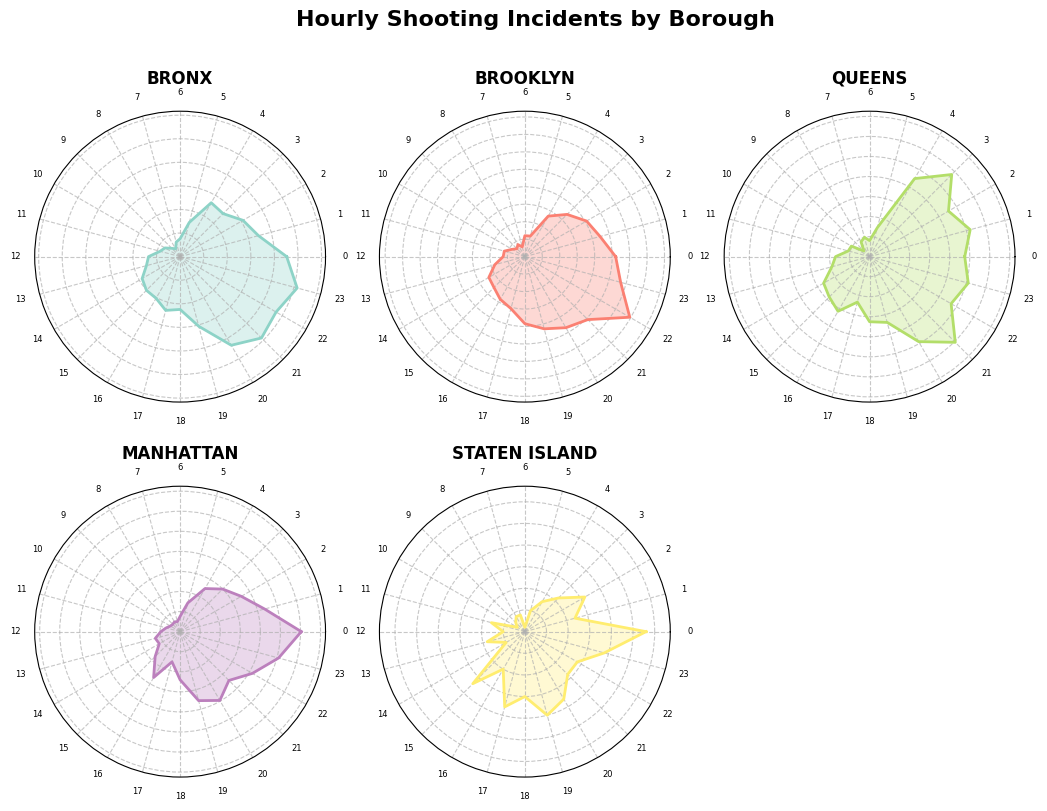

In [27]:
df = pd.DataFrame(data)

# Get the list of boroughs
boroughs = df['boro'].unique()

# Set up radar plot parameters
num_vars = 24  # Hours in the day
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close circle

# Create figure with dynamic number of subplots
n_boroughs = len(boroughs)
cols = min(3, n_boroughs)  # Max 3 columns
rows = (n_boroughs + cols - 1) // cols  # Calculate rows needed
fig, axs = plt.subplots(rows, cols, subplot_kw=dict(polar=True), figsize=(12, 4 * rows))
axs = axs.flatten()

# Colors for consistency
colors = plt.cm.Set3(np.linspace(0, 1, n_boroughs))

# Store handles and labels for the legend
handles = []
labels = []

for i, (boro, color) in enumerate(zip(boroughs, colors)):
    ax = axs[i]

    # Count shootings per hour
    hourly_counts = df[df['boro'] == boro]['hour'].value_counts().sort_index()
    counts = [hourly_counts.get(h, 0) for h in range(24)]
    counts += counts[:1]  # Close radar

    # Plot radar
    line, = ax.plot(angles, counts, linewidth=2, color=color, label=boro)
    ax.fill(angles, counts, color=color, alpha=0.3)
    ax.set_title(boro, size=12, pad=20, fontweight='bold')

    # X-axis: show 0-23 hours with small font
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(range(24), size=6)

    # Y-axis: remove all labels
    ax.set_yticklabels([])

    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(0, max(max(counts) for b in boroughs) * 1.2)

    # Collect handles and labels for the legend
    handles.append(line)
    labels.append(boro)

# Hide unused subplots
for j in range(len(boroughs), len(axs)):
    fig.delaxes(axs[j])

# Main title
fig.suptitle('Hourly Shooting Incidents by Borough', size=16, fontweight='bold', y=1.01, x=0.45)

# Adjust layout
plt.tight_layout()
fig.subplots_adjust(right=0.85)

plt.show()

>To tell visitors of safer hours in NYC, we plotted radar charts of shooting incidents by hour for each borough. The Bronx and Brooklyn experienced most incidents between 8 PM and 2 AM, with a spike at midnight, suggesting greater danger at night. Queens was similar, with a spike between 10 PM and 1 AM. Manhattan saw fewer, with minor peaks from 2–3 PM and 10–11 PM, indicating daytime as safer. Staten Island saw the least, with a minor peak from 12–2 PM. Visitors need to be careful at nighttime, particularly in the Bronx and Brooklyn, while the daytime in Manhattan is safe.

In [39]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster, HeatMap
from geopy.distance import distance

# Load your dataset (replace this with actual data loading)
# df = pd.read_csv("your_data.csv")
df = pd.DataFrame(data)  # replace 'data' with your dataset variable

# Convert 'date' column to datetime and extract month
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Count incidents per season
spring_cases = len(df[df['month'].isin([3, 4, 5])])
summer_cases = len(df[df['month'].isin([6, 7, 8])])
autumn_cases = len(df[df['month'].isin([9, 10, 11])])
winter_cases = len(df[df['month'].isin([12, 1, 2])])
total_cases = len(df)

# Define landmarks with coordinates
landmarks = {
    "Times Square": (40.7580, -73.9855),
    "Central Park": (40.7829, -73.9654),
    "Brooklyn Bridge": (40.7061, -73.9969),
    "Statue of Liberty": (40.6892, -74.0445),
    "Empire State Building": (40.7484, -73.9857),
    "Grand Central Terminal": (40.7527, -73.9772),
    "The High Line": (40.7479, -74.0049),
    "One World Trade Center": (40.7127, -74.0134),
    "Rockefeller Center": (40.7587, -73.9787),
    "The MET": (40.7794, -73.9632)
}

# Create a base Folium map
nyc_map = folium.Map(location=[40.7580, -73.8255], zoom_start=10.2, tiles=None)
folium.TileLayer('CartoDB Positron', name='CartoDB Positron', control=False).add_to(nyc_map)


# Add all incidents as a cluster layer
all_layer = folium.FeatureGroup(name='Other', show=True)
all_cluster = MarkerCluster().add_to(all_layer)


for _, row in df.iterrows():
    popup = f"""<b>Date:</b> {row['date']}<br><b>Borough:</b> {row['boro']}<br><b>Precinct:</b> {row['precinct']}<br><b>If Dead:</b> {row['ifdead']}<br><b>Perp Race:</b> {row['perp_race']}<br><b>Vic Race:</b> {row['vic_race']}<br><b>Hour:</b> {row['hour']}"""
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='red' if row['ifdead'] else 'blue',
        fill=True,
        fill_opacity=0.7,
        popup=popup
    ).add_to(all_cluster)

all_layer.add_to(nyc_map)

# Add a HeatMap layer based on incident density
heat_data = [[row['lat'], row['lon']] for _, row in df.iterrows()]
heat_layer = folium.FeatureGroup(name='Heatmap', show=True)
HeatMap(heat_data, radius=15, blur=20).add_to(heat_layer)
heat_layer.add_to(nyc_map)

# Add layers for each landmark (1000m range)
for name, center in landmarks.items():
    subset = df[df.apply(lambda row: distance((row['lat'], row['lon']), center).meters <= 1000, axis=1)]
    layer = folium.FeatureGroup(name=name, show=True)  # selected by default
    cluster = MarkerCluster().add_to(layer)

    for _, row in subset.iterrows():
        popup = f"""<b>Date:</b> {row['date']}<br><b>Borough:</b> {row['boro']}<br><b>Precinct:</b> {row['precinct']}<br><b>If Dead:</b> {row['ifdead']}<br><b>Perp Race:</b> {row['perp_race']}<br><b>Vic Race:</b> {row['vic_race']}<br><b>Hour:</b> {row['hour']}"""
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color='darkred' if row['ifdead'] else 'darkblue',
            fill=True,
            fill_opacity=0.7,
            popup=popup
        ).add_to(cluster)

    layer.add_to(nyc_map)

# Add layer control (with all layers expanded by default)
folium.LayerControl(collapsed=False).add_to(nyc_map)

# Add seasonal case totals in a fixed info box
seasonal_info = f"""
<div class="season-info" style="
    position: absolute;
    bottom: 10px;
    right: 10px;
    background-color: white;
    border: 2px solid black;
    padding: 10px;
    font-size: 13px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    width: 250px;
    z-index: 9999;
">
    <b>Seasonal Case Totals:</b><br>
    Spring (Mar-May): {spring_cases} cases<br>
    Summer (Jun-Aug): {summer_cases} cases<br>
    Autumn (Sep-Nov): {autumn_cases} cases<br>
    Winter (Dec-Feb): {winter_cases} cases<br>
    <b>Total:</b> {total_cases} cases
</div>

<script>
document.addEventListener('DOMContentLoaded', function() {{
    var mapContainer = document.querySelector('.leaflet-container');
    var infoBox = document.querySelector('.season-info');
    if (mapContainer && infoBox) {{
        mapContainer.appendChild(infoBox);
    }}
}});
</script>
"""
nyc_map.get_root().html.add_child(folium.Element(seasonal_info))

# Add Select All / Deselect All buttons for layers
custom_js = """
<script>
document.addEventListener('DOMContentLoaded', function() {
    var layerControl = document.getElementsByClassName('leaflet-control-layers')[0];
    var buttonContainer = document.createElement('div');
    buttonContainer.style.padding = '5px';

    var selectAllButton = document.createElement('button');
    selectAllButton.innerHTML = 'Select All';
    selectAllButton.style.marginRight = '5px';
    selectAllButton.style.padding = '5px';
    selectAllButton.onclick = function() {
        var checkboxes = layerControl.getElementsByTagName('input');
        for (var i = 0; i < checkboxes.length; i++) {
            if (!checkboxes[i].checked) {
                checkboxes[i].click();
            }
        }
    };

    var deselectAllButton = document.createElement('button');
    deselectAllButton.innerHTML = 'Deselect All';
    deselectAllButton.style.padding = '5px';
    deselectAllButton.onclick = function() {
        var checkboxes = layerControl.getElementsByTagName('input');
        for (var i = 0; i < checkboxes.length; i++) {
            if (checkboxes[i].checked) {
                checkboxes[i].click();
            }
        }
    };

    buttonContainer.appendChild(selectAllButton);
    buttonContainer.appendChild(deselectAllButton);
    layerControl.insertBefore(buttonContainer, layerControl.firstChild);
});
</script>
"""
nyc_map.get_root().html.add_child(folium.Element(custom_js))

# Save the map as an HTML file
nyc_map.save('nyc_landmark_filter_map.html')

# Display in Jupyter Notebook if available
try:
    from IPython.display import IFrame
    IFrame('nyc_landmark_filter_map.html', width='100%', height='750px')
except:
    print("Map saved to 'nyc_landmark_filter_map.html'")


>We created a heatmap showing the density of shooting incidents across the city. High-density clusters in Brooklyn and the Bronx, with incident counts up to 1511 and 702, marked these areas as hotspots, suggesting higher risks for visitors. Manhattan showed lower density, with counts around 189, indicating it’s safer for tourists. Staten Island and parts of Queens had the fewest incidents, with counts as low as 31, making them safer options for exploration.

In [53]:
# Ensure date is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Convert numeric month to month name
df['month_name'] = df['month'].apply(lambda x: calendar.month_name[x])

# Group data by date and month name to count incidents per day
daily_counts = df.groupby(['date', 'month_name']).size().reset_index(name='daily_shootings')


july_mask = daily_counts['month_name'] == 'July'
max_july_value = daily_counts.loc[july_mask, 'daily_shootings'].max()
daily_counts = daily_counts[~((july_mask) & (daily_counts['daily_shootings'] == max_july_value))]

# Define month order for the plot
month_order = list(calendar.month_name)[1:]  # Skip empty string at index 0

# Create the Plotly box plot
fig = px.box(daily_counts, 
             x='month_name', 
             y='daily_shootings',
             category_orders={'month_name': month_order},
             title="Distribution of Daily Shooting Incidents per Month",
             labels={'month_name': 'Month', 'daily_shootings': 'Number of Shootings per Day'},
             color='month_name',  # Color each month differently
             color_discrete_sequence=px.colors.sequential.Plasma)
fig.update_layout(
    width=800,  # Set the width of the plot
    height=480,  # Set the height of the plot
    title_x=0.5
)
# Save the plot as an HTML file (like the map)
fig.write_html('shootings_boxplot.html')

# Display the plot
fig.show()


>Here, we created a box plot showing the distribution of daily shooting incidents per month from 2016 to 2022. July and August had the highest median daily incidents (around 5–6), with some days reaching up to 20 incidents, indicating higher risks in summer. January and February showed the lowest medians (around 2–3), with fewer outliers, suggesting safer winter months for visitors.

### Weather dataset

In [13]:
import numpy as np
import pandas as pd
import calendar
from bokeh.models import ColumnDataSource, HoverTool, LabelSet, Select, CustomJS
from bokeh.layouts import column
from bokeh.plotting import figure, show, output_file
from bokeh.palettes import Reds256, Blues256, Greys256

# Assume data2 exists and contains 'month', 'temperature', 'rain', 'cloudcover'

# Convert numeric 'month' values to full month names using calendar.month_name
data2['month_name'] = data2['month'].apply(lambda x: calendar.month_name[x])

# Group by 'month_name' and calculate the average temperature, rain, and cloudcover
average_data_by_month = data2.groupby('month_name')[['temperature', 'rain', 'cloudcover']].mean().reset_index()

# Sort the months in order
months_order = list(calendar.month_name[1:])
average_data_by_month['month_name'] = pd.Categorical(average_data_by_month['month_name'], categories=months_order, ordered=True)
average_data_by_month = average_data_by_month.sort_values('month_name')

# Add formatted labels
average_data_by_month['temperature_label'] = average_data_by_month['temperature'].apply(lambda x: f"{x:.1f}")
average_data_by_month['rain_label'] = average_data_by_month['rain'].apply(lambda x: f"{x:.1f}")
average_data_by_month['cloudcover_label'] = average_data_by_month['cloudcover'].apply(lambda x: f"{x:.1f}")

# Function to create gradient colors
def get_gradient_colors(values, palette):
    min_val, max_val = min(values), max(values)
    if min_val == max_val:
        normalized = [0.5] * len(values)
    else:
        normalized = [(v - min_val) / (max_val - min_val) for v in values]
        normalized = [1 - n for n in normalized]
    palette_length = len(palette)
    colors = [palette[int(n * (palette_length - 1))] for n in normalized]
    return colors

# Add gradient colors
average_data_by_month['temperature_colors'] = get_gradient_colors(average_data_by_month['temperature'].tolist(), Reds256)
average_data_by_month['rain_colors'] = get_gradient_colors(average_data_by_month['rain'].tolist(), Blues256)
average_data_by_month['cloudcover_colors'] = get_gradient_colors(average_data_by_month['cloudcover'].tolist(), Greys256)

# ColumnDataSource
source = ColumnDataSource(average_data_by_month)

# Create bar chart function
def create_bar_chart(metric, color_field):
    max_value = average_data_by_month[metric].max()
    p = figure(
        x_range=months_order,
        y_range=(0, max_value * 1.2),  # Prevent bars from stretching
        title=f"Average {metric} by Month",
        toolbar_location="above",
        tools="reset",
        width=800,
        height=510  # 10px higher
    )
    p.min_border_top = 50  # Add space above

    hover = HoverTool()
    hover.tooltips = [("Month", "@month_name"), (f"Average {metric}", f"@{metric}{{0.00}}")]
    p.add_tools(hover)

    p.vbar(x='month_name', top=metric, source=source, width=0.6, fill_color=color_field, line_color="black", line_width=2)

    labels = LabelSet(x='month_name', y=metric, text=f"{metric}_label", level='glyph',
                      x_offset=0, y_offset=10, source=source,
                      text_font_size="8pt", text_color="black", text_align="center")
    p.add_layout(labels)

    p.xaxis.axis_label = "Month"
    p.yaxis.axis_label = f"Average {metric}"
    p.xaxis.major_label_orientation = "vertical"
    p.grid.grid_line_color = "white"

    return p

# Create plots
temperature_plot = create_bar_chart("temperature", "temperature_colors")
rain_plot = create_bar_chart("rain", "rain_colors")
cloudcover_plot = create_bar_chart("cloudcover", "cloudcover_colors")

# Set visibility
rain_plot.visible = False
cloudcover_plot.visible = False

# Select widget
select = Select(title="Select Grouping:", value="temperature", options=["temperature", "rain", "cloudcover"])
select.js_on_change('value', CustomJS(args=dict(
    temperature_plot=temperature_plot, 
    rain_plot=rain_plot, 
    cloudcover_plot=cloudcover_plot), code="""
    var selected_value = cb_obj.value;
    temperature_plot.visible = false;
    rain_plot.visible = false;
    cloudcover_plot.visible = false;

    if (selected_value === 'temperature') {
        temperature_plot.visible = true;
    } else if (selected_value === 'rain') {
        rain_plot.visible = true;
    } else if (selected_value === 'cloudcover') {
        cloudcover_plot.visible = true;
    }
"""))

# Layout
layout = column(select, temperature_plot, rain_plot, cloudcover_plot)

# Output and show
output_file("interactive_weather_plots.html")
show(layout)


>To give readers an overview of the weathers in NYC ,we analyzed monthly weather patterns in NYC with histograms. Average temperatures peaked in July–August at around 25°C, aligning with higher shooting incidents, while January–February were coldest at 0–5°C, matching safer periods. Rainfall was highest in April and October (around 0.15 mm daily), potentially reducing incidents, and lowest in January–February (around 0.05 mm). Cloud cover was highest in February and September (around 50%), offering no clear link to safety but indicating less sunny days for tourists.


# Genre
>**Which genre of data story did you use?**
>
>We adopted the Magazine Style for our data story. This genre aligns with our goal of addressing a central question through a combination of narrative text and supporting visualizations, all within a single frame. By prioritizing textual storytelling while using charts and images as supplementary evidence, we ensure clarity and focus. The Magazine Style is particularly effective for conveying complex messages, as it allows readers to follow a structured narrative while engaging with data-driven insights in a digestible format.

>**Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?**
>
>Visual Structuring:
>
>- Progress Bar / Timebar: Based on our most basic visualization framework, the narrative is more logical.
>- Consistent Visual Platform:Consistency in colors, symbols, and layout ensures that the audience can easily follow the narrative.
>
>Highlighting:
>
>- Zooming:This function allows readers to better view details. For example, in the map of NYC. Zooming allows readers to view details that interest them.
>- Feature Distinction: This helps in highlighting what is most important or relevant at our visualization.
>
>**Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?**
>
>Ordering:
>
>- We used a linear ordering approach. This method allows precise control over the narrative pace and the sequence of information, guiding the audience step-by-step through complex data and insights.
>
>Interactivity:
>
>- Hover Highlighting / Details: For example, in the "Distribution of daily shooting incidents per month from 2016 to 2022" chart, hovering highlights specific details, helping users explore particular data points.
>- Filtering / Selection / Search: Users can filter data by month, allowing them to focus on subsets of information that interest them.
>- Navigation Buttons: These buttons facilitate easy movement between different sections or charts, increasing interactivity and engagement.
>
>Messaging:
>
>- Captions / Headlines: Essential for framing the meaning of the data visualizations and guiding the viewer's understanding.
>- Annotations: Provide explanations for key data points, ensuring clarity and context.
>- Introductory Text and Summary / Synthesis: The introductory text sets the stage for the narrative, while the summary helps readers review and understand the conclusions drawn from the charts.

<br>

# Visualizations
>Explain the visualizations you've chosen.\
>Why are they right for the story you want to tell?\
>In this project, we investigated whether weather conditions—especially temperature—affect shooting incidents in New York City. To answer this, we took a step-by-step approach:
First, we mapped broad trends over time and across different hours of the day, using time-series charts and heatmaps to spot patterns. Next, we analyzed annual weather variations to set the stage. Then, we directly compared shootings with temperature, rainfall, and cloud cover, visualizing potential links through scatter plots and correlation matrices. Finally, we ran statistical tests to confirm what the graphs hinted at: hotter days consistently correlated with more shootings.
This layered analysis not only makes the case visually but also backs it up with numbers—showing how NYC’s weather might influence public safety.


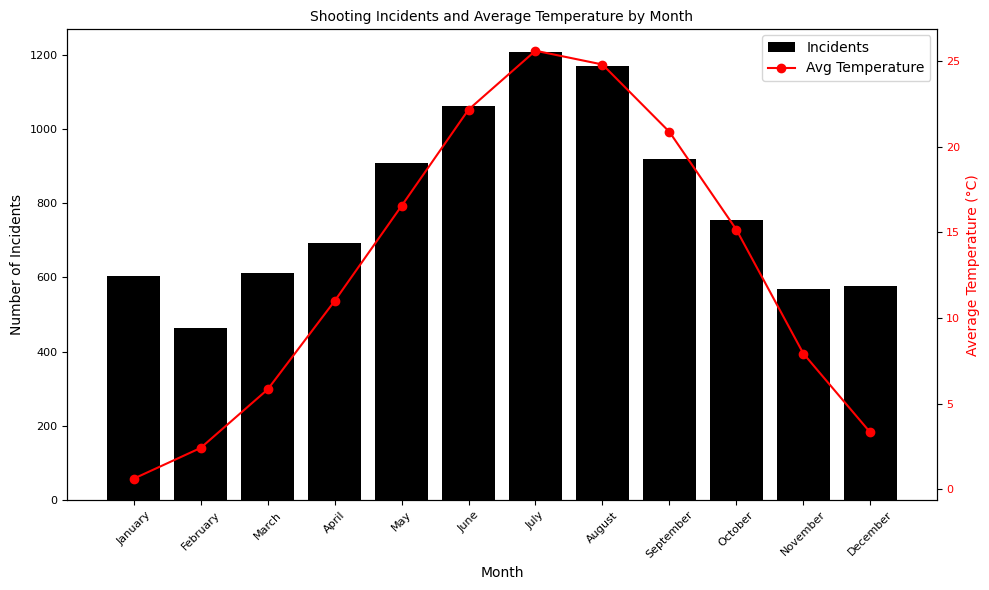

In [81]:
# Step 1: Aggregate incidents by month
incidents_by_month = data.groupby('month').size().reindex(range(1, 13), fill_value=0)

# Step 2: Aggregate average temperature by month
avg_temp_by_month = data2.groupby('month')['temperature'].mean().reindex(range(1, 13), fill_value=0)

# Step 3: Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram for incidents (bars in black)
months = range(1, 13)
bars = ax1.bar(months, incidents_by_month.values, width=0.8, color='black', label='Incidents', align='center')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Incidents', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set x-axis labels to month names
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
ax1.set_xticks(months)
ax1.set_xticklabels(month_names, rotation=45)

# Create a second y-axis for the temperature line
ax2 = ax1.twinx()
line, = ax2.plot(months, avg_temp_by_month.values, color='red', marker='o', label='Avg Temperature')
ax2.set_ylabel('Average Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title('Shooting Incidents and Average Temperature by Month')

# Legend customization
legend_position = 'upper right'  # Change this to 'lower left', 'center', etc.
# Custom anchor position for full control
fig.legend([bars, line], ['Incidents', 'Avg Temperature'],
           loc='upper left', bbox_to_anchor=(0.76, 0.945))  # Adjust these numbers

# Layout adjustments before saving
plt.tight_layout()

# Save the figure
plt.savefig("temp.png", dpi=300)

# Show the plot
plt.show()


>The dual-axis plot shows a potential correlation between NYC's shooting incidents and average temperature. Incidents peak in July (around 1200) when temperatures are highest (25°C), and both are lowest in February (around 400 incidents, 0°C). Higher incidents align with warmer months (June–August), while colder months (January–February, November–December) have fewer incidents, suggesting temperature may influence incident rates, though other factors could also play a role.

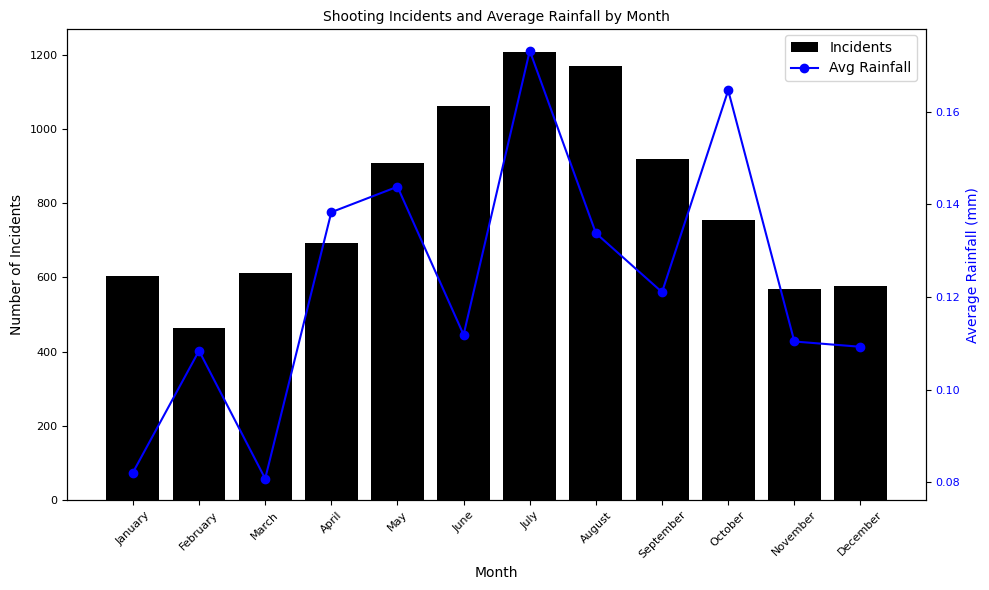

In [82]:
# Step 1: Aggregate incidents by month
incidents_by_month = data.groupby('month').size().reindex(range(1, 13), fill_value=0)

# Step 2: Aggregate average rainfall by month
avg_rain_by_month = data2.groupby('month')['rain'].mean().reindex(range(1, 13), fill_value=0)

# Step 3: Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram for incidents (bars in black)
months = range(1, 13)
bars = ax1.bar(months, incidents_by_month.values, width=0.8, color='black', label='Incidents', align='center')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Incidents', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set x-axis labels to month names
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
ax1.set_xticks(months)
ax1.set_xticklabels(month_names, rotation=45)

# Create a second y-axis for the rainfall line
ax2 = ax1.twinx()
line, = ax2.plot(months, avg_rain_by_month.values, color='blue', marker='o', label='Avg Rainfall')
ax2.set_ylabel('Average Rainfall (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Title
plt.title('Shooting Incidents and Average Rainfall by Month')

# Legend customization
legend_position = 'upper right'  # Change this to 'lower left', 'center', etc.
# Custom anchor position for full control
fig.legend([bars, line], ['Incidents', 'Avg Rainfall'],
           loc='upper left', bbox_to_anchor=(0.783, 0.945))  # Adjust these numbers

# Layout adjustments before saving
plt.tight_layout()

# Save the figure
plt.savefig("rain.png", dpi=300)

# Show the plot
plt.show()


>The dual-axis plot shows no clear correlation between NYC's shooting incidents and average rainfall. Incidents peak in July (around 1200) while rainfall also peaks (0.16 mm), but August has high incidents (around 1000) with low rainfall (0.10 mm). Similarly, September sees high rainfall (0.14 mm) but fewer incidents (around 700). Incidents and rainfall fluctuate independently across months, suggesting rainfall has little direct influence on shooting incidents.

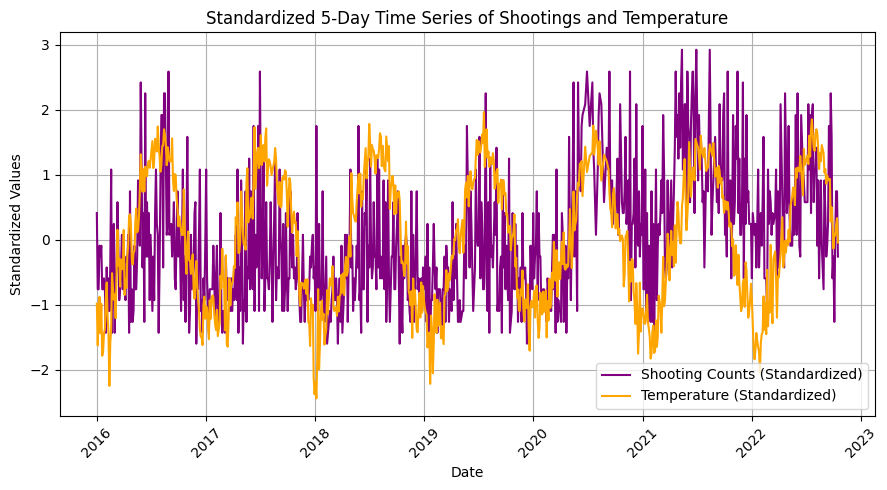

In [56]:
# Step 1: Aggregate the data
data2['date'] = pd.to_datetime(data2['day'])

shootings = data.groupby('date').size().reset_index(name='shooting_count')
shootings['date'] = pd.to_datetime(shootings['date'])
shootings = shootings.set_index('date').resample('3D').sum().reset_index()

# For temperature (already daily averages, take mean over 5-day periods)
temperature = data2[['date', 'temperature']].drop_duplicates(subset='date')
temperature['date'] = pd.to_datetime(temperature['date'])
temperature = temperature.set_index('date').resample('3D').mean().reset_index()

# Step 2: Merge the datasets on the 5-day interval dates (inner join)
merged = pd.merge(shootings, temperature, on='date', how='inner')

# Filter out zero-filled days
merged = merged[(merged['shooting_count'] > 0) & (merged['temperature'].notna())]

# Step 3: Remove outliers using the IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

merged = remove_outliers(merged, 'shooting_count')
merged = remove_outliers(merged, 'temperature')

# Step 4: Standardize the data
scaler = StandardScaler()
standardized_data = scaler.fit_transform(merged[['shooting_count', 'temperature']])
merged['shooting_count_std'] = standardized_data[:, 0]
merged['temperature_std'] = standardized_data[:, 1]

# Step 5: Plot the standardized time series with 5-day intervals
plt.figure(figsize=(9, 5))
plt.plot(merged['date'], merged['shooting_count_std'], label='Shooting Counts (Standardized)', color='purple')
plt.plot(merged['date'], merged['temperature_std'], label='Temperature (Standardized)', color='orange')
plt.xlabel('Date')
plt.ylabel('Standardized Values')
plt.title('Standardized 5-Day Time Series of Shootings and Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save the plot to a file
plt.savefig('Time-serie graph.png')

# Show the plot
plt.show()


>We standardized the number of daily shootings and daily weather temperatures and drew a five-year time series chart, showing the changing trends of the number of shootings and temperature between 2016 and 2023. This reflects the potential similarity of the changing trends between the two.

In [57]:
output_notebook()

# Assume data (shooting data) and data2 (weather data) are already loaded as pandas DataFrames
# Ensure date fields are in datetime format
data['date'] = pd.to_datetime(data['date'])
data2['day'] = pd.to_datetime(data2['day'])

# 1. Construct monthly shooting incident counts
monthly_shooting = data.groupby(['year', 'month']).size().reset_index(name='Crime Count')

# 2. Construct monthly weather statistics
# 2.1 Determine if it’s a rainy day (rain > 0)
data2['rain_day'] = (data2['rain'] > 0).astype(int)

# 2.2 Aggregate daily rain (use max value per day)
daily_rain = data2.groupby(['year', 'month', 'day'])['rain'].max().reset_index()

# 2.3 Calculate monthly rainy days
monthly_rain_days = daily_rain.groupby(['year', 'month'])['rain'].sum().reset_index(name='rain')

# 2.4 Calculate monthly weather averages (excluding rain)
monthly_weather_avg = data2.groupby(['year', 'month'])[['temperature', 'cloudcover']].mean().reset_index()

# 2.5 Merge weather information
monthly_weather = pd.merge(monthly_weather_avg, monthly_rain_days, on=['year', 'month'])

# 3. Merge weather and shooting data
merged = pd.merge(monthly_shooting, monthly_weather, on=['year', 'month'])

# 4. Calculate correlation matrix with capitalized column names
merged = merged.rename(columns={
    'Crime Count': 'Crime Count',  # Already capitalized
    'temperature': 'Temperature',
    'rain': 'Rain',
    'cloudcover': 'Cloudcover'
})
corr_matrix = merged[['Crime Count', 'Temperature', 'Rain', 'Cloudcover']].corr()

# 5. Convert correlation matrix to long format for visualization
corr_df = corr_matrix.reset_index().melt(id_vars='index')
corr_df.columns = ['x', 'y', 'value']
corr_df['value_str'] = corr_df['value'].round(2).astype(str)

# 6. Bokeh heatmap drawing
colors = RdBu[11][::-1]  # Blue to red gradient
mapper = LinearColorMapper(palette=colors, low=-1, high=1)
source = ColumnDataSource(corr_df)

p = figure(
    title="Correlation Matrix",
    x_range=['Crime Count', 'Temperature', 'Rain', 'Cloudcover'],  # Capitalized labels
    y_range=['Crime Count', 'Temperature', 'Rain', 'Cloudcover'][::-1],  # Capitalized, reversed
    toolbar_location=None, tools="", x_axis_location="above",
    width=800, height=600  # Increased width to 800
)

# Set larger font sizes for x-axis and y-axis labels and ticks
p.xaxis.axis_label_text_font_size = "12pt"  # Larger x-axis title font
p.yaxis.axis_label_text_font_size = "12pt"  # Larger y-axis title font
p.xaxis.major_label_text_font_size = "11pt"  # Larger x-axis tick labels
p.yaxis.major_label_text_font_size = "11pt" # Larger y-axis tick labels

# Set title properties for larger font and centering
p.title.text_font_size = "15pt"  # Title font size
p.title.align = "center"  # Center the title

p.rect(x="x", y="y", width=1, height=1, source=source,
       fill_color=transform('value', mapper), line_color=None)

# Add numerical labels
labels = LabelSet(x='x', y='y', text='value_str', level='glyph',
                  x_offset=-15, y_offset=-10, source=source, text_font_size="12pt")
p.add_layout(labels)

# Add color bar
color_bar = ColorBar(color_mapper=mapper, ticker=BasicTicker(),
                     location=(0, 0), label_standoff=12)
p.add_layout(color_bar, 'right')

# Rotate x-axis labels, remove grid lines
p.xaxis.major_label_orientation = np.pi / 4
p.grid.grid_line_color = None

# Save the plot to an HTML file
output_file("correlation_heatmap.html")

# Display the chart
show(p)


Loading BokehJS ...

>We calculated the correlation matrix using a Pearson correlation coefficient, showing the correlation between the number of crimes (Crime Count) and three weather variables - temperature (temperature), number of rainy days (rain) and cloud cover (cloudcover). The data is calculated based on the monthly average and the number of rainy days. 

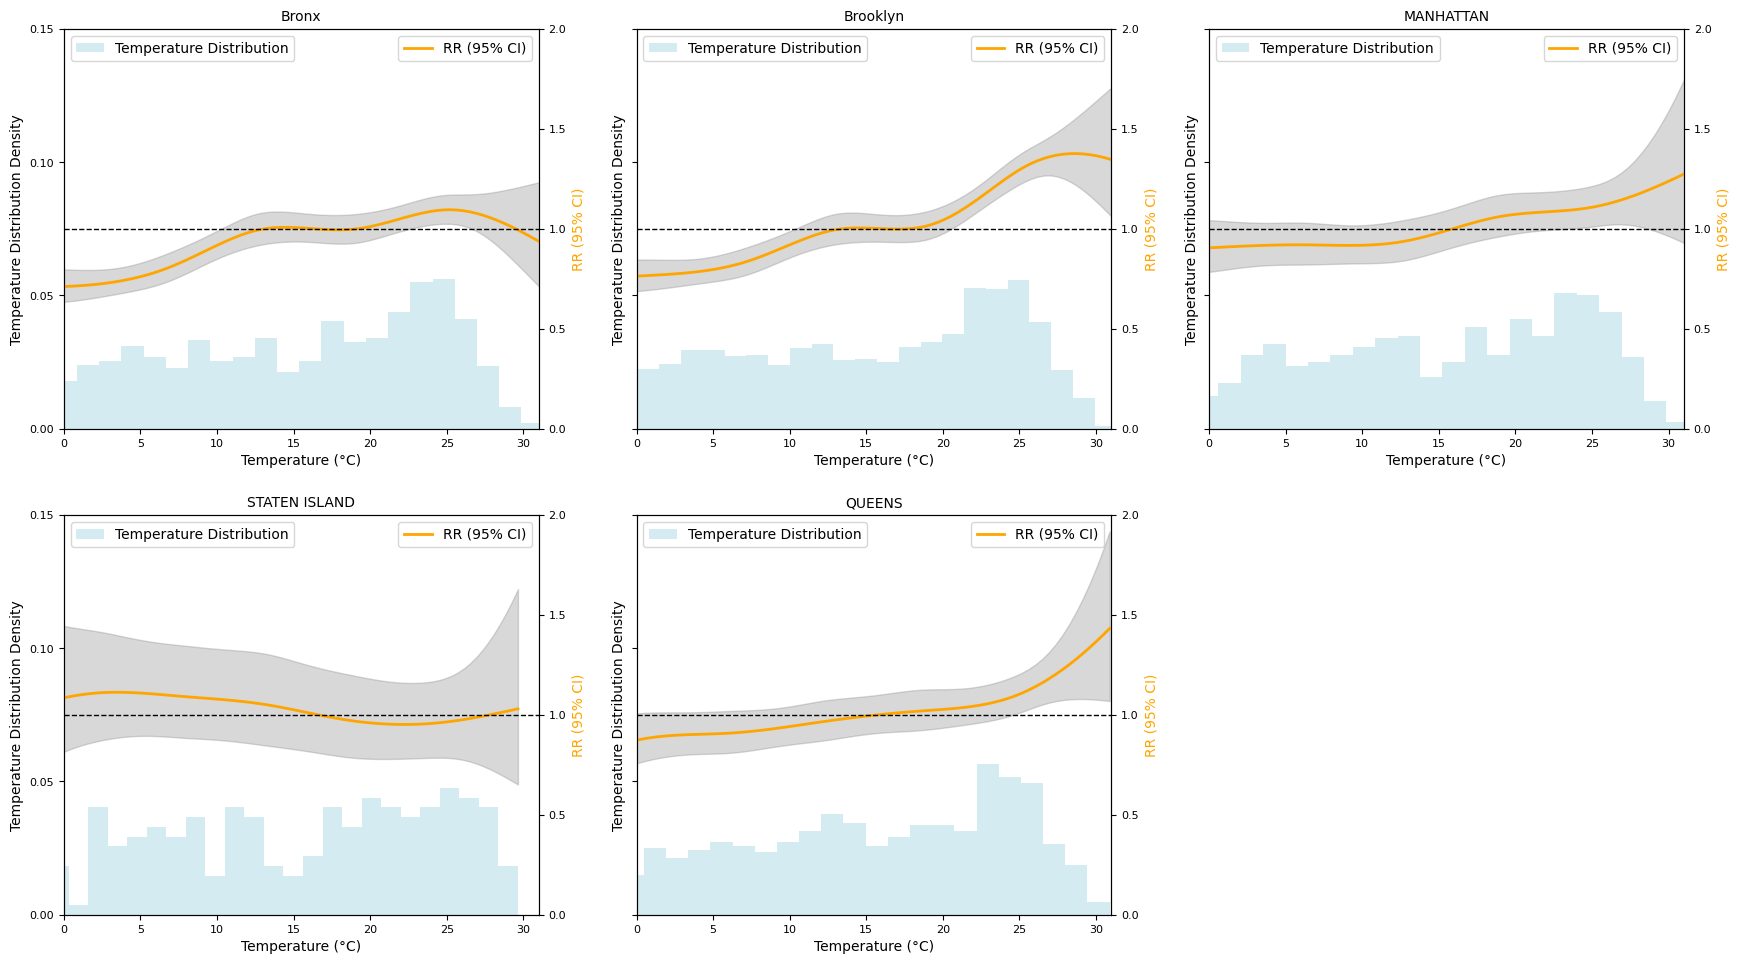

In [93]:
# Step 1: Data Processing
# Aggregate temperature data (average by date)
temperature_daily = data2.groupby('date')['temperature'].mean().reset_index()

# Aggregate shooting event data (count by date and borough)
shootings = data.groupby(['date', 'boro']).size().reset_index(name='shooting_count')

# Merge shooting events and temperature data (by date)
merged = pd.merge(shootings, temperature_daily, on='date', how='inner')
if merged.empty:
    print("Merged dataset is empty. Please check if the dates overlap!")
    exit()

# Step 2: Calculate RR and Confidence Intervals
boroughs = merged['boro'].unique()
rr_data = {}

for boro in boroughs:
    # Extract and clean data for current borough
    boro_data = merged[merged['boro'] == boro].copy()
    boro_data = boro_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['temperature', 'shooting_count'])

    if len(boro_data) < 2:
        print(f"Not enough valid data for {boro}, skipping!")
        continue

    # Prepare variables
    X = boro_data['temperature'].values.reshape(-1, 1)  # Should be 2D
    y = boro_data['shooting_count'].values

    try:
        # Fit GAM model with adjusted smoothing parameters
        gam = PoissonGAM(s(0, n_splines=10, lam=2)).fit(X, y)
        
    except Exception as e:
        print(f"Fit failed for {boro}: {e}")
        continue

    # Generate predicted RR (relative risk)
    temp_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    pred = gam.predict(temp_range)
    conf_int = gam.confidence_intervals(temp_range, width=0.95)

    # Baseline temperature as median
    baseline_temp = np.median(X)
    baseline_pred = gam.predict([[baseline_temp]])[0]

    rr = pred / baseline_pred
    rr_lower = conf_int[:, 0] / baseline_pred
    rr_upper = conf_int[:, 1] / baseline_pred

    rr_data[boro] = pd.DataFrame({
        'temperature': temp_range.flatten(),
        'rr': rr,
        'rr_lower': rr_lower,
        'rr_upper': rr_upper
    })

# Step 3: Plotting
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# Borough labels (translated)
borough_labels = {
    'BRONX': 'Bronx',
    'BROOKLYN': 'Brooklyn'
}

# Create a layout for subplots dynamically based on the number of boroughs
n_boroughs = len(rr_data)
n_rows = (n_boroughs // 3) + (1 if n_boroughs % 3 > 0 else 0)  # Number of rows required for the plots

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows), sharey='row')  # Adjust rows based on borough count

# Flatten axes to iterate over
axes = axes.flatten()

# Iterate over each borough
for i, boro in enumerate(rr_data.keys()):
    boro_temp = merged[merged['boro'] == boro]['temperature']

    ax1 = axes[i]  # Select subplot for this borough
    ax2 = ax1.twinx()  # Right axis for RR curve

    # Temperature distribution histogram
    ax1.hist(boro_temp, bins=30, density=True, alpha=0.5, color='#ADD8E6', label='Temperature Distribution')

    # RR curve
    rr = rr_data[boro]
    ax2.plot(rr['temperature'], rr['rr'], color='#FFA500', linewidth=2, label='RR (95% CI)')
    ax2.fill_between(rr['temperature'], rr['rr_lower'], rr['rr_upper'], color='gray', alpha=0.3)

    # Add horizontal dashed line at RR = 1
    ax2.axhline(1, color='black', linestyle='--', linewidth=1)

    # Adjust axis limits
    ax1.set_ylim(0, 0.15)  # For histogram
    ax2.set_ylim(0, 2.0)   # For RR curve

    ax1.set_ylabel('Temperature Distribution Density')
    ax2.set_ylabel('RR (95% CI)', color='#FFA500')

    ax1.set_xlim(0, 31)  # Temperature range
    ax1.set_xlabel('Temperature (°C)')

    ax1.set_title(borough_labels.get(boro, boro))
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))

    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

# Hide empty subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout to reduce white space
plt.tight_layout(pad=2.0)  # Increase padding to reduce empty spaces
plt.subplots_adjust(left=0.05, right=0.95)  # Adjust left and right margins

plt.savefig('temperature_rr_plot_with_rr1_line.png')



>We present the relationship between temperature (percentage) and relative risk (RR) of shootings in the five boroughs of New York City (Bronx, Brooklyn, Manhattan, Staten Island, and Queens). The chart analyzes the effect of temperature on shooting rates using a generalized additive model (GAM) and presents the results in a visual format.

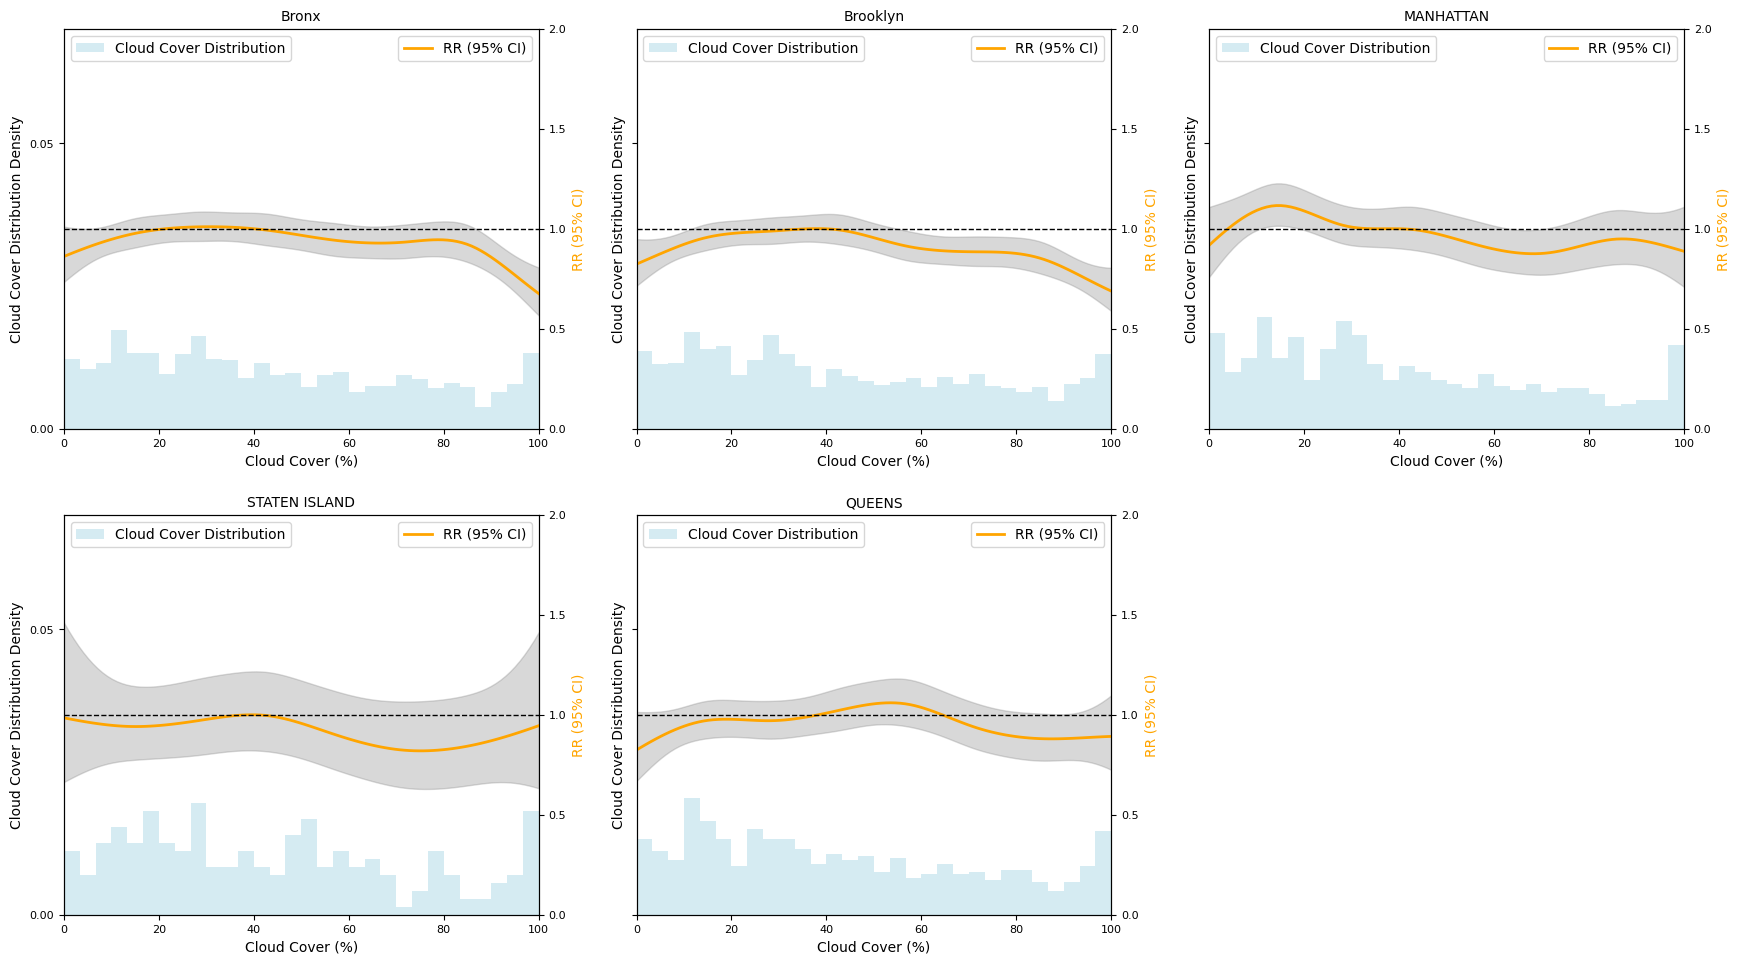

In [94]:
# Step 1: Data Processing
# Aggregate cloud cover data (average by date)
cloudcover_daily = data2.groupby('date')['cloudcover'].mean().reset_index()

# Aggregate shooting event data (count by date and borough)
shootings = data.groupby(['date', 'boro']).size().reset_index(name='shooting_count')

# Merge shooting events and cloud cover data (by date)
merged = pd.merge(shootings, cloudcover_daily, on='date', how='inner')
if merged.empty:
    print("Merged dataset is empty. Please check if the dates overlap!")
    exit()

# Step 2: Calculate RR and Confidence Intervals
boroughs = merged['boro'].unique()
rr_data = {}

for boro in boroughs:
    # Extract and clean data for current borough
    boro_data = merged[merged['boro'] == boro].copy()
    boro_data = boro_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['cloudcover', 'shooting_count'])

    if len(boro_data) < 2:
        print(f"Not enough valid data for {boro}, skipping!")
        continue

    # Prepare variables
    X = boro_data['cloudcover'].values.reshape(-1, 1)  # Should be 2D
    y = boro_data['shooting_count'].values

    try:
        # Fit GAM model with adjusted smoothing parameters
        gam = PoissonGAM(s(0, n_splines=10, lam=4)).fit(X, y)
        
    except Exception as e:
        print(f"Fit failed for {boro}: {e}")
        continue

    # Generate predicted RR (relative risk)
    temp_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    pred = gam.predict(temp_range)
    conf_int = gam.confidence_intervals(temp_range, width=0.95)

    # Baseline cloud cover as median
    baseline_temp = np.median(X)
    baseline_pred = gam.predict([[baseline_temp]])[0]

    rr = pred / baseline_pred
    rr_lower = conf_int[:, 0] / baseline_pred
    rr_upper = conf_int[:, 1] / baseline_pred

    rr_data[boro] = pd.DataFrame({
        'cloudcover': temp_range.flatten(),
        'rr': rr,
        'rr_lower': rr_lower,
        'rr_upper': rr_upper
    })

# Step 3: Plotting
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# Borough labels (translated)
borough_labels = {
    'BRONX': 'Bronx',
    'BROOKLYN': 'Brooklyn'
}

# Create a layout for subplots dynamically based on the number of boroughs
n_boroughs = len(rr_data)
n_rows = (n_boroughs // 3) + (1 if n_boroughs % 3 > 0 else 0)  # Number of rows required for the plots

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows), sharey='row')  # Adjust rows based on borough count

# Flatten axes to iterate over
axes = axes.flatten()

# Iterate over each borough
for i, boro in enumerate(rr_data.keys()):
    boro_cloudcover = merged[merged['boro'] == boro]['cloudcover']

    ax1 = axes[i]  # Select subplot for this borough
    ax2 = ax1.twinx()  # Right axis for RR curve

    # Cloud cover distribution histogram
    ax1.hist(boro_cloudcover, bins=30, density=True, alpha=0.5, color='#ADD8E6', label='Cloud Cover Distribution')
    
    # RR curve
    rr = rr_data[boro]
    ax2.plot(rr['cloudcover'], rr['rr'], color='#FFA500', linewidth=2, label='RR (95% CI)')
    ax2.fill_between(rr['cloudcover'], rr['rr_lower'], rr['rr_upper'], color='gray', alpha=0.3)

    # Add horizontal dashed line at RR = 1
    ax2.axhline(1, color='black', linestyle='--', linewidth=1)

    # Adjust axis limits
    ax1.set_ylim(0, 0.07)  # For histogram
    ax2.set_ylim(0, 2.0)   # For RR curve

    ax1.set_ylabel('Cloud Cover Distribution Density')
    ax2.set_ylabel('RR (95% CI)', color='#FFA500')

    ax1.set_xlim(0, 100)  # Cloud cover range
    ax1.set_xlabel('Cloud Cover (%)')

    ax1.set_title(borough_labels.get(boro, boro))
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))

    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

# Hide empty subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout to reduce white space
plt.tight_layout(pad=2.0)  # Increase padding to reduce empty spaces
plt.subplots_adjust(left=0.05, right=0.95)  # Adjust left and right margins

plt.savefig('cloudcover_rr_plot_with_rr1_line.png')


>We present the relationship between cloud cover (percentage) and relative risk (RR) of shootings in the five boroughs of New York City (Bronx, Brooklyn, Manhattan, Staten Island, and Queens). The chart analyzes the effect of cloud cover on shooting rates using a generalized additive model (GAM) and presents the results in a visual format.

# Discussion
>Think critically about your creation\
>What went well?\
>What is still missing? What could be improved?, Why? \
>The project successfully delivered 10 visualizations to inform tourists about NYC safety, leveraging shooting and weather data from 2016–2022. Despite the limited data, the preprocessing was thorough and effective, ensuring a solid foundation for analysis. Key visualizations, such as the interactive time series chart tracking incident numbers, the radar chart illustrating hourly borough patterns, and the dual-axis histograms correlating incidents with temperature and rainfall, provided valuable insights into seasonal and weather-related trends. The boxplot highlighted peak shooting months, while the correlation matrix and relative risk (RR) charts with confidence intervals added statistical rigor to the findings. Teamwork went well, with seamless collaboration ensuring engaging. \
>The project could be enhanced by addressing several areas. First, the limited data, spanning only 2016–2022, restricts the depth of analysis; expanding it with additional years or integrating alternative data sources (e.g., real-time crime reports or historical weather archives) would provide a more robust dataset. Second, analyzing demographic details (‘perp_race’, ‘vic_race’, ‘ifdead’) through visualizations like pie charts or heatmaps could reveal victim and perpetrator profiles, offering tourists a clearer picture of safety risks. Third, incorporating external factors such as holidays, major events, or socioeconomic indicators into statistical models like the generalized additive model (GAM) would uncover additional drivers of shooting incidents, improving predictive accuracy. 

# Contributions
>Who did what?
>You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain).
>It is not OK simply to write "All group members contributed equally".\
>Every member of the group contributed actively to the project. Chenxi created the heatmap and histogram visualizations, and handled the data cleaning and preprocessing tasks such as formatting the date fields and generating month name features. Qiwen created the correlation charts and the relative risk chart, and worked together with Chen on building and designing the website. Xinya created the boxplot and radar chart visualizations. All group members contributed to writing the captions, conclusions, and documentation for the project.